# Hotel Booking Cancellation Prediction

## Notebook 04 — Stage 7: Model Optimization and Final Evaluation

**Module:** IT3051 – Fundamentals of Data Mining  
**Group:** Group 27 – Entropy Zero  
**Task:** Supervised binary classification  
**Target:** `is_canceled`

- `0` — Not Cancelled
- `1` — Cancelled

### Stage 7 objective

This notebook continues directly from the **executed Stage 6 evidence**. It will:

1. load and audit the saved Stage 6 validation results;
2. tune only the two models actually shortlisted in Notebook 03;
3. evaluate imbalance-sensitive parameters during tuning;
4. retain the finalized Stage 4 feature set unless training-only evidence justifies a change;
5. compare baseline and tuned chronological-CV performance;
6. select one final algorithm using the pre-registered rule;
7. optimize the classification threshold using **training-only chronological out-of-fold probabilities**;
8. write a formal **FINAL DECISION LOCK**;
9. only after that lock, load the untouched chronological final test set;
10. fit the frozen pipeline on all training observations and evaluate it once on the final test set;
11. save the deployable preprocessing + classifier pipeline, threshold metadata, result evidence, and model-input contract.

### Test-set rule

The final test files are **not read anywhere before the FINAL DECISION LOCK**. They cannot influence hyperparameter selection, feature decisions, class-weight decisions, algorithm selection, or threshold selection.

## 1. Stage 6 Evidence Review

Notebook 03 was executed successfully with the same grouped expanding-window chronological validation strategy used here.

The actual Stage 6 shortlist was:

- **XGBoost**
- **Random Forest**

The executed Stage 6 evidence showed:

- XGBoost mean ROC-AUC: **0.8743**
- Random Forest mean ROC-AUC: **0.8725**
- ROC-AUC difference: approximately **0.0018**, inside the project-defined `0.005` practical-closeness tolerance.
- Random Forest had slightly higher mean PR-AUC and precision.
- XGBoost had higher mean recall and F1 at the baseline `0.5` threshold.

Therefore both ensemble models advanced to Stage 7 rather than declaring a final model in Stage 6.


The cells below load the saved Stage 6 CSV evidence and verify the critical shortlist metrics against the actual executed Notebook 03 outputs before Stage 7 tuning begins.

In [1]:
import json
import platform
import time
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

import xgboost
from xgboost import XGBClassifier

from IPython.display import Markdown, display

RANDOM_STATE = 42
PRACTICAL_ROC_AUC_GAP = 0.005

# State guards make the test-set ordering explicit within a notebook run.
FINAL_DECISION_LOCK_WRITTEN = False
FINAL_TEST_EVALUATED_THIS_RUN = False

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("joblib:", joblib.__version__)
print("Random state:", RANDOM_STATE)

Python: 3.14.6
pandas: 3.0.6
NumPy: 2.5.3
scikit-learn: 1.9.1
XGBoost: 3.4.1
joblib: 1.6.0
Random state: 42


### Locate the local repository

The repository root is detected automatically from the current working directory or its parents. This supports local VS Code/Jupyter execution when the kernel starts from either the repository root or the `notebooks/` directory.

No absolute Windows path, Google Colab path, Google Drive mount, or automatic Git clone is used.

In [2]:
def find_repository_root(start_path=None):
    """Locate the cloned project root from the current working directory."""
    start = Path(start_path or Path.cwd()).resolve()
    candidates = (start, *start.parents)

    for candidate in candidates:
        if (
            (candidate / ".git").exists()
            and (candidate / "data" / "raw" / "hotel_bookings.csv").exists()
        ):
            return candidate

    # Fallback for an exported project copy where .git metadata is absent.
    for candidate in candidates:
        if (
            (candidate / "data" / "raw" / "hotel_bookings.csv").exists()
            and (candidate / "README.md").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the IT3051 project repository root. "
        "Open VS Code from inside the cloned repository (or its notebooks/ "
        "subfolder), then run the notebook with the project Python kernel."
    )


REPO_ROOT = find_repository_root()

MODELING_REPORT_DIR = REPO_ROOT / "reports" / "modeling"
STAGE7_FIGURE_DIR = REPO_ROOT / "reports" / "figures" / "stage7"
MODELS_DIR = REPO_ROOT / "models"
DOCS_DIR = REPO_ROOT / "docs"

for directory in [
    MODELING_REPORT_DIR,
    STAGE7_FIGURE_DIR,
    MODELS_DIR,
    DOCS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Repository root:", REPO_ROOT)
print("Stage 7 modelling directory:", MODELING_REPORT_DIR)
print("Stage 7 figure directory:", STAGE7_FIGURE_DIR)
print("Models directory:", MODELS_DIR)
print("Docs directory:", DOCS_DIR)

Repository root: C:\Users\sudul\Downloads\FDM\Assignment\IT3051-Group27-Hotel-Cancellation-Prediction\IT3051-Group27-Hotel-Cancellation-Prediction
Stage 7 modelling directory: C:\Users\sudul\Downloads\FDM\Assignment\IT3051-Group27-Hotel-Cancellation-Prediction\IT3051-Group27-Hotel-Cancellation-Prediction\reports\modeling
Stage 7 figure directory: C:\Users\sudul\Downloads\FDM\Assignment\IT3051-Group27-Hotel-Cancellation-Prediction\IT3051-Group27-Hotel-Cancellation-Prediction\reports\figures\stage7
Models directory: C:\Users\sudul\Downloads\FDM\Assignment\IT3051-Group27-Hotel-Cancellation-Prediction\IT3051-Group27-Hotel-Cancellation-Prediction\models
Docs directory: C:\Users\sudul\Downloads\FDM\Assignment\IT3051-Group27-Hotel-Cancellation-Prediction\IT3051-Group27-Hotel-Cancellation-Prediction\docs


In [3]:
STAGE6_BASELINE_PATH = (
    MODELING_REPORT_DIR / "stage6_baseline_results.csv"
)
STAGE6_FOLD_PATH = (
    MODELING_REPORT_DIR / "stage6_fold_results.csv"
)
STAGE6_CV_SUMMARY_PATH = (
    MODELING_REPORT_DIR / "stage6_cv_fold_summary.csv"
)
STAGE6_SHORTLIST_PATH = (
    MODELING_REPORT_DIR / "stage6_stage7_shortlist.csv"
)

stage6_required_files = [
    STAGE6_BASELINE_PATH,
    STAGE6_FOLD_PATH,
    STAGE6_CV_SUMMARY_PATH,
    STAGE6_SHORTLIST_PATH,
]

missing_stage6_files = [
    str(path.relative_to(REPO_ROOT))
    for path in stage6_required_files
    if not path.exists()
]

if missing_stage6_files:
    raise FileNotFoundError(
        "Required executed Stage 6 evidence is missing:\n"
        + "\n".join(f" - {path}" for path in missing_stage6_files)
        + "\nRun and save Notebook 03 first."
    )

stage6_baseline_results = pd.read_csv(STAGE6_BASELINE_PATH)
stage6_fold_results = pd.read_csv(STAGE6_FOLD_PATH)
stage6_cv_fold_summary = pd.read_csv(STAGE6_CV_SUMMARY_PATH)
stage6_shortlist = pd.read_csv(STAGE6_SHORTLIST_PATH)

print("Loaded executed Stage 6 evidence.")
display(
    stage6_baseline_results
    .sort_values("ROC-AUC Mean", ascending=False)
    .reset_index(drop=True)
)
print("\nStage 6 shortlist:")
display(stage6_shortlist)

Loaded executed Stage 6 evidence.


,Model,ROC-AUC Mean,ROC-AUC Std,PR-AUC Mean,PR-AUC Std,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,Fit Time Seconds Mean,Fit Time Seconds Std,Scoring Time Seconds Mean,Scoring Time Seconds Std
0,XGBoost,0.874277,0.032124,0.806179,0.076445,0.797793,0.029793,0.759911,0.042051,0.631636,0.115986,0.687317,0.083115,1.492297,0.162092,0.119371,0.006996
1,Random Forest,0.872491,0.031844,0.807082,0.069301,0.789551,0.036787,0.824942,0.040051,0.519876,0.155371,0.628446,0.123453,78.617638,34.891140,0.266332,0.031524
2,Logistic Regression,0.836245,0.034976,0.751060,0.083411,0.759528,0.027427,0.700044,0.063802,0.574481,0.121257,0.626482,0.088939,2.772985,0.736946,0.091133,0.017076
3,Decision Tree,0.701098,0.046720,0.522543,0.080715,0.724651,0.034260,0.614114,0.074189,0.620707,0.089342,0.616968,0.079986,11.014589,4.987546,0.079258,0.007081



Stage 6 shortlist:


,Model,ROC-AUC Mean,ROC-AUC Std,PR-AUC Mean,F1 Mean,Recall Mean,Precision Mean,Fit Time Seconds Mean,Scoring Time Seconds Mean,ROC-AUC Gap from Best,Within 0.005 of Best,Interpretability,Deployment Complexity
0,Random Forest,0.872491,0.031844,0.807082,0.628446,0.519876,0.824942,78.617638,0.266332,0.001786,True,Moderate,Moderate
1,XGBoost,0.874277,0.032124,0.806179,0.687317,0.631636,0.759911,1.492297,0.119371,0.000000,True,Moderate to lower,Moderate; extra xgboost dependency


In [4]:
# Verify critical values against the actual executed Notebook 03 outputs.
EXECUTED_STAGE6_REFERENCE = {
    "Random Forest": {
        "ROC-AUC Mean": 0.872491,
        "ROC-AUC Std": 0.031844,
        "PR-AUC Mean": 0.807082,
        "F1 Mean": 0.628446,
        "Recall Mean": 0.519876,
        "Precision Mean": 0.824942,
    },
    "XGBoost": {
        "ROC-AUC Mean": 0.874277,
        "ROC-AUC Std": 0.032124,
        "PR-AUC Mean": 0.806179,
        "F1 Mean": 0.687317,
        "Recall Mean": 0.631636,
        "Precision Mean": 0.759911,
    },
}

for model_name, expected_metrics in EXECUTED_STAGE6_REFERENCE.items():
    matched = stage6_baseline_results[
        stage6_baseline_results["Model"] == model_name
    ]
    assert len(matched) == 1, (
        f"Expected exactly one Stage 6 baseline row for {model_name}."
    )
    row = matched.iloc[0]

    for metric_name, expected_value in expected_metrics.items():
        assert np.isclose(
            float(row[metric_name]),
            expected_value,
            atol=5e-6,
        ), (
            f"Saved Stage 6 value mismatch for {model_name} / {metric_name}: "
            f"found {row[metric_name]}, expected approximately {expected_value}."
        )

shortlisted_models = stage6_shortlist["Model"].tolist()

assert len(shortlisted_models) == 2, (
    f"Expected two Stage 6 shortlisted models, found {shortlisted_models}."
)
assert set(shortlisted_models) == {"Random Forest", "XGBoost"}, (
    "The saved shortlist does not match the final executed Notebook 03. "
    f"Found: {shortlisted_models}"
)

print("Stage 6 saved evidence matches the executed Notebook 03 reference.")
print("Actual Stage 7 models:", shortlisted_models)

rf_row = stage6_shortlist[
    stage6_shortlist["Model"] == "Random Forest"
].iloc[0]
xgb_row = stage6_shortlist[
    stage6_shortlist["Model"] == "XGBoost"
].iloc[0]

print(
    "\nWhy both advanced:"
    f"\n - XGBoost had the highest mean ROC-AUC "
    f"({xgb_row['ROC-AUC Mean']:.4f})."
    f"\n - Random Forest was only "
    f"{rf_row['ROC-AUC Gap from Best']:.4f} behind, inside the "
    f"{PRACTICAL_ROC_AUC_GAP:.3f} project tolerance."
    f"\n - Random Forest PR-AUC={rf_row['PR-AUC Mean']:.4f}, "
    f"precision={rf_row['Precision Mean']:.4f}."
    f"\n - XGBoost PR-AUC={xgb_row['PR-AUC Mean']:.4f}, "
    f"recall={xgb_row['Recall Mean']:.4f}, "
    f"F1={xgb_row['F1 Mean']:.4f}."
)

Stage 6 saved evidence matches the executed Notebook 03 reference.
Actual Stage 7 models: ['Random Forest', 'XGBoost']

Why both advanced:
 - XGBoost had the highest mean ROC-AUC (0.8743).
 - Random Forest was only 0.0018 behind, inside the 0.005 project tolerance.
 - Random Forest PR-AUC=0.8071, precision=0.8249.
 - XGBoost PR-AUC=0.8062, recall=0.6316, F1=0.6873.


## 2. Load Training Data Only

Stage 7 optimization initially loads only the committed Stage 4 training handoff:

- `data/processed/X_train_engineered.csv`
- `data/processed/y_train.csv`

The chronological final-test files are deliberately not opened here.

`booking_month` is restored to string after CSV loading because CSV type inference may otherwise treat it as numeric.

In [5]:
X_TRAIN_PATH = (
    REPO_ROOT / "data" / "processed" / "X_train_engineered.csv"
)
Y_TRAIN_PATH = (
    REPO_ROOT / "data" / "processed" / "y_train.csv"
)

missing_training_files = [
    str(path.relative_to(REPO_ROOT))
    for path in [X_TRAIN_PATH, Y_TRAIN_PATH]
    if not path.exists()
]

if missing_training_files:
    raise FileNotFoundError(
        "Required Stage 4 training files are missing:\n"
        + "\n".join(f" - {path}" for path in missing_training_files)
        + "\nRun Notebook 02 or restore the committed processed files."
    )

X_train = pd.read_csv(X_TRAIN_PATH)
y_train_frame = pd.read_csv(Y_TRAIN_PATH)

TARGET = "is_canceled"

if list(y_train_frame.columns) != [TARGET]:
    raise ValueError(
        f"Expected y_train.csv to contain exactly one column named "
        f"'{TARGET}', but found: {list(y_train_frame.columns)}"
    )

y_train = y_train_frame[TARGET].copy()

X_train["booking_month"] = X_train["booking_month"].astype(str)

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

print("Training predictors loaded:", X_train.shape)
print("Training target loaded:", y_train.shape)
print("Final test data loaded before decision lock: NO")

Training predictors loaded: (95401, 32)
Training target loaded: (95401,)
Final test data loaded before decision lock: NO


## 3. Training-Data Integrity Contract

The same finalized Stage 4 contract used in Notebook 03 is enforced again. Stage 7 stops rather than silently proceeding if the training handoff has changed.

In [6]:
EXPECTED_TRAIN_ROWS = 95_401

EXPECTED_PREDICTORS = [
    "hotel",
    "lead_time",
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "reserved_room_type",
    "deposit_type",
    "customer_type",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "total_nights",
    "total_guests",
    "has_children",
    "has_agent",
    "has_company",
    "is_zero_guest",
    "is_zero_night",
    "booking_month",
]

FORBIDDEN_COLUMNS = {
    "is_canceled",
    "reservation_status",
    "reservation_status_date",
    "assigned_room_type",
    "booking_changes",
    "days_in_waiting_list",
    "agent",
    "company",
    "arrival_date",
    "booking_date",
}

assert len(X_train) == EXPECTED_TRAIN_ROWS
assert len(y_train) == EXPECTED_TRAIN_ROWS
assert X_train.shape[1] == 32
assert list(X_train.columns) == EXPECTED_PREDICTORS
assert X_train.index.equals(y_train.index)
assert set(y_train.dropna().unique()) == {0, 1}
assert not y_train.isna().any()

forbidden_present = sorted(
    FORBIDDEN_COLUMNS.intersection(X_train.columns)
)
assert not forbidden_present, (
    f"Forbidden leakage/timing/helper columns found: {forbidden_present}"
)

missing_counts = X_train.isna().sum()
nonzero_missing = missing_counts[missing_counts > 0]

expected_missing_counts = pd.Series(
    {"children": 4, "country": 415},
    dtype="int64",
)

assert set(nonzero_missing.index) == set(expected_missing_counts.index)

for column, expected_count in expected_missing_counts.items():
    assert int(missing_counts[column]) == expected_count, (
        f"Expected {expected_count} missing values in {column}, "
        f"found {int(missing_counts[column])}."
    )

assert pd.api.types.is_string_dtype(X_train["booking_month"])

# Explicitly confirm no final-test variables exist yet.
assert "X_test" not in globals()
assert "y_test" not in globals()

print("All Stage 4 training-data integrity checks passed.")
display(nonzero_missing.to_frame("Missing Count"))

All Stage 4 training-data integrity checks passed.


,Missing Count
children,4
country,415


## 4. Recreate the Exact Stage 6 Chronological Validation Framework

`booking_date` is reconstructed only as split metadata:

**booking_date = arrival_date − lead_time days**

It is never included in the predictor matrix.

The same five grouped expanding windows from Notebook 03 are reconstructed. Complete booking-date groups remain together, and every fold must satisfy:

`max(training booking_date) < min(validation booking_date)`

In [7]:
arrival_date_for_cv = pd.to_datetime(
    X_train["arrival_date_year"].astype(str)
    + "-"
    + X_train["arrival_date_month"].astype(str)
    + "-"
    + X_train["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d",
    errors="raise",
)

booking_date_for_cv = (
    arrival_date_for_cv
    - pd.to_timedelta(X_train["lead_time"], unit="D")
)

assert booking_date_for_cv.notna().all()
assert "booking_date" not in X_train.columns
assert booking_date_for_cv.max() == pd.Timestamp("2017-01-11")

print(
    "Training booking-date range:",
    booking_date_for_cv.min().date(),
    "to",
    booking_date_for_cv.max().date(),
)

Training booking-date range: 2013-06-24 to 2017-01-11


In [8]:
def build_grouped_expanding_time_folds(
    booking_dates,
    initial_train_fraction=0.50,
    validation_fraction=0.10,
    n_splits=5,
):
    """Build complete-date expanding chronological validation folds."""
    booking_dates = pd.Series(booking_dates).reset_index(drop=True)

    if booking_dates.isna().any():
        raise ValueError("booking_dates contains missing values.")

    expected_final_fraction = (
        initial_train_fraction + n_splits * validation_fraction
    )
    if not np.isclose(expected_final_fraction, 1.0):
        raise ValueError(
            "Fractions must cover the full training set."
        )

    date_counts = booking_dates.value_counts().sort_index()
    cumulative_fraction = date_counts.cumsum() / len(booking_dates)

    target_end_fractions = [
        initial_train_fraction + i * validation_fraction
        for i in range(n_splits + 1)
    ]

    boundaries = []

    for target_fraction in target_end_fractions:
        if np.isclose(target_fraction, 1.0):
            boundary = date_counts.index[-1]
        else:
            eligible = cumulative_fraction[
                cumulative_fraction <= target_fraction
            ]
            if eligible.empty:
                raise ValueError(
                    f"No complete booking-date group fits target "
                    f"fraction {target_fraction:.2f}."
                )
            boundary = eligible.index[-1]

        boundaries.append(boundary)

    if len(set(boundaries)) != len(boundaries):
        raise ValueError(
            "One or more chronological boundaries collapsed "
            "onto the same booking date."
        )

    folds = []

    for fold_number in range(1, n_splits + 1):
        train_end = boundaries[fold_number - 1]
        validation_end = boundaries[fold_number]

        train_mask = booking_dates <= train_end
        validation_mask = (
            (booking_dates > train_end)
            & (booking_dates <= validation_end)
        )

        train_idx = np.flatnonzero(train_mask.to_numpy())
        validation_idx = np.flatnonzero(validation_mask.to_numpy())

        train_dates = booking_dates.iloc[train_idx]
        validation_dates = booking_dates.iloc[validation_idx]

        assert len(train_idx) > 0
        assert len(validation_idx) > 0
        assert train_dates.max() < validation_dates.min()
        assert set(train_dates.unique()).isdisjoint(
            set(validation_dates.unique())
        )

        folds.append((train_idx, validation_idx))

    return folds, boundaries


time_folds, fold_boundaries = build_grouped_expanding_time_folds(
    booking_date_for_cv,
    initial_train_fraction=0.50,
    validation_fraction=0.10,
    n_splits=5,
)

stage7_fold_summary_rows = []

for fold_number, (train_idx, validation_idx) in enumerate(
    time_folds,
    start=1,
):
    train_dates = booking_date_for_cv.iloc[train_idx]
    validation_dates = booking_date_for_cv.iloc[validation_idx]

    stage7_fold_summary_rows.append(
        {
            "Fold": fold_number,
            "Training Start Date": train_dates.min().date(),
            "Training End Date": train_dates.max().date(),
            "Validation Start Date": validation_dates.min().date(),
            "Validation End Date": validation_dates.max().date(),
            "Training Rows": len(train_idx),
            "Validation Rows": len(validation_idx),
            "Training Cancellation %": (
                y_train.iloc[train_idx].mean() * 100
            ),
            "Validation Cancellation %": (
                y_train.iloc[validation_idx].mean() * 100
            ),
        }
    )

stage7_fold_summary = pd.DataFrame(stage7_fold_summary_rows)

# Verify that Notebook 04 has reconstructed the same fold boundaries/row counts
# saved by the executed Notebook 03.
stage6_fold_check = stage6_cv_fold_summary.copy()
for col in [
    "Training Start Date",
    "Training End Date",
    "Validation Start Date",
    "Validation End Date",
]:
    stage6_fold_check[col] = pd.to_datetime(
        stage6_fold_check[col]
    ).dt.date

comparison_cols = [
    "Fold",
    "Training Start Date",
    "Training End Date",
    "Validation Start Date",
    "Validation End Date",
    "Training Rows",
    "Validation Rows",
]

pd.testing.assert_frame_equal(
    stage7_fold_summary[comparison_cols].reset_index(drop=True),
    stage6_fold_check[comparison_cols].reset_index(drop=True),
    check_dtype=False,
)

display(
    stage7_fold_summary.style.format(
        {
            "Training Cancellation %": "{:.2f}",
            "Validation Cancellation %": "{:.2f}",
        }
    )
)

print("Notebook 04 reconstructed exactly the Stage 6 fold structure.")

,Fold,Training Start Date,Training End Date,Validation Start Date,Validation End Date,Training Rows,Validation Rows,Training Cancellation %,Validation Cancellation %
0,1,2013-06-24,2016-02-23,2016-02-24,2016-04-16,47392,9686,40.42,36.06
1,2,2013-06-24,2016-04-16,2016-04-17,2016-07-05,57078,9692,39.68,34.36
2,3,2013-06-24,2016-07-05,2016-07-06,2016-09-19,66770,9412,38.91,36.37
3,4,2013-06-24,2016-09-19,2016-09-20,2016-11-20,76182,9366,38.60,31.80
4,5,2013-06-24,2016-11-20,2016-11-21,2017-01-11,85548,9853,37.85,43.45


Notebook 04 reconstructed exactly the Stage 6 fold structure.


## 5. Recreate the Finalized Preprocessor

The preprocessing definition is unchanged from Notebooks 02 and 03.

- General numerical features: median imputation + `RobustScaler`
- `children`: most-frequent imputation + `RobustScaler`
- Binary indicators: passthrough
- Categoricals: constant `"Unknown"` imputation + `OneHotEncoder(handle_unknown="ignore")`

The transformer is returned **unfitted** and remains inside every model Pipeline so each CV training fold learns its own imputation, scaling, and categorical vocabulary.

In [9]:
CATEGORICAL_COLUMNS = [
    "hotel",
    "arrival_date_month",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "deposit_type",
    "customer_type",
    "booking_month",
]

BINARY_COLUMNS = [
    "is_repeated_guest",
    "has_children",
    "has_agent",
    "has_company",
    "is_zero_guest",
    "is_zero_night",
]

NUMERIC_COLUMNS_TO_SCALE = [
    "lead_time",
    "arrival_date_year",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "total_nights",
    "total_guests",
]

CHILDREN_COLUMN = ["children"]

all_grouped_columns = (
    NUMERIC_COLUMNS_TO_SCALE
    + CHILDREN_COLUMN
    + BINARY_COLUMNS
    + CATEGORICAL_COLUMNS
)

assert len(all_grouped_columns) == 32
assert set(all_grouped_columns) == set(EXPECTED_PREDICTORS)
assert len(all_grouped_columns) == len(set(all_grouped_columns))


def make_finalized_preprocessor():
    """Return a fresh, unfitted copy of the finalized Stage 4 preprocessor."""
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
        ]
    )

    children_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("scaler", RobustScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value="Unknown",
                ),
            ),
            (
                "encoder",
                OneHotEncoder(handle_unknown="ignore"),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                NUMERIC_COLUMNS_TO_SCALE,
            ),
            (
                "children",
                children_pipeline,
                CHILDREN_COLUMN,
            ),
            (
                "binary",
                "passthrough",
                BINARY_COLUMNS,
            ),
            (
                "categorical",
                categorical_pipeline,
                CATEGORICAL_COLUMNS,
            ),
        ]
    )


def make_model_pipeline(classifier):
    """Return a fresh preprocessing + classifier pipeline."""
    return Pipeline(
        steps=[
            ("preprocessor", make_finalized_preprocessor()),
            ("classifier", clone(classifier)),
        ]
    )


print(make_finalized_preprocessor())
print("\nPreprocessor is defined but not fitted.")

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['lead_time', 'arrival_date_year',
                                  'arrival_date_week_number',
                                  'arrival_date_day_of_month',
                                  'stays_in_weekend_nights',
                                  'stays_in_week_nights', 'adults', 'babies',
                                  'previous_cancellations',
                                  'previous_bookings_not_canceled', 'adr'...
                                  'has_agent', 'has_company', 'is_zero_guest',
                                  'is_zero_night']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                     

## 6. Stage 7 Hyperparameter Search Strategy

Only the **actual Stage 6 shortlist** is tuned.

### Random Forest

Random Forest uses `RandomizedSearchCV` over tree count, depth, split/leaf constraints, feature subsampling, and `class_weight`.

Notebook 03 showed a mean Random Forest fold fit time of about **78.62 seconds** for only one 250-tree configuration. A 25–40 configuration search would therefore be disproportionately expensive on a local machine, especially because some candidates use up to 800 trees. For this project, the Random Forest search is intentionally limited to **12 randomized configurations × 5 chronological folds**.

### XGBoost

The executed Stage 6 XGBoost baseline was much faster (about **1.49 seconds mean fit time per fold**), so a broader **30-configuration randomized search** is computationally defensible.

### Parallelism

`RandomizedSearchCV` itself uses `n_jobs=1`, while each RF/XGBoost estimator may use its own CPU threads (`n_jobs=-1`). This avoids nested parallelism where both the search and estimator try to use every core simultaneously.

### Optimization objective

Both searches optimize:

`scoring="roc_auc"`

using exactly the same five chronological folds.

In [10]:
RF_RANDOM_ITERATIONS = 12
XGB_RANDOM_ITERATIONS = 30
SEARCH_N_JOBS = 1

rf_base = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_param_distributions = {
    "classifier__n_estimators": [200, 300, 400, 600, 800],
    "classifier__max_depth": [None, 10, 20, 30, 40],
    "classifier__min_samples_split": [2, 5, 10, 20, 30],
    "classifier__min_samples_leaf": [1, 2, 4, 6, 10],
    "classifier__max_features": ["sqrt", "log2", 0.5, 0.75],
    "classifier__class_weight": [
        None,
        "balanced",
        "balanced_subsample",
    ],
}

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_param_distributions = {
    "classifier__n_estimators": [200, 300, 400, 600, 800],
    "classifier__learning_rate": [
        0.03,
        0.05,
        0.08,
        0.10,
        0.15,
        0.20,
    ],
    "classifier__max_depth": [3, 4, 5, 6, 8, 9],
    "classifier__min_child_weight": [1, 2, 5, 10],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "classifier__reg_alpha": [0.0, 0.01, 0.1, 0.5, 1.0],
    "classifier__reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
    "classifier__scale_pos_weight": [1.0, 1.5, 2.0],
}


def make_search_for_model(model_name):
    """Create the correct Stage 7 search object for a shortlisted model."""
    if model_name == "Random Forest":
        return RandomizedSearchCV(
            estimator=make_model_pipeline(rf_base),
            param_distributions=rf_param_distributions,
            n_iter=RF_RANDOM_ITERATIONS,
            scoring="roc_auc",
            cv=time_folds,
            refit=True,
            random_state=RANDOM_STATE,
            n_jobs=SEARCH_N_JOBS,
            verbose=2,
            return_train_score=False,
            error_score="raise",
        )

    if model_name == "XGBoost":
        return RandomizedSearchCV(
            estimator=make_model_pipeline(xgb_base),
            param_distributions=xgb_param_distributions,
            n_iter=XGB_RANDOM_ITERATIONS,
            scoring="roc_auc",
            cv=time_folds,
            refit=True,
            random_state=RANDOM_STATE,
            n_jobs=SEARCH_N_JOBS,
            verbose=2,
            return_train_score=False,
            error_score="raise",
        )

    # These branches keep the notebook methodologically robust if Stage 6
    # evidence is ever regenerated with a different valid shortlist.
    if model_name == "Logistic Regression":
        logistic_base = LogisticRegression(
            solver="liblinear",
            max_iter=2000,
            random_state=RANDOM_STATE,
        )
        logistic_grid = {
            "classifier__C": [0.01, 0.1, 1.0, 10.0],
            "classifier__class_weight": [None, "balanced"],
        }
        return GridSearchCV(
            estimator=make_model_pipeline(logistic_base),
            param_grid=logistic_grid,
            scoring="roc_auc",
            cv=time_folds,
            refit=True,
            n_jobs=SEARCH_N_JOBS,
            verbose=2,
            return_train_score=False,
            error_score="raise",
        )

    if model_name == "Decision Tree":
        tree_base = DecisionTreeClassifier(
            random_state=RANDOM_STATE,
        )
        tree_grid = {
            "classifier__criterion": ["gini", "entropy"],
            "classifier__max_depth": [None, 5, 10, 20],
            "classifier__min_samples_split": [2, 10, 20],
            "classifier__min_samples_leaf": [1, 5, 10],
            "classifier__class_weight": [None, "balanced"],
        }
        return GridSearchCV(
            estimator=make_model_pipeline(tree_base),
            param_grid=tree_grid,
            scoring="roc_auc",
            cv=time_folds,
            refit=True,
            n_jobs=SEARCH_N_JOBS,
            verbose=2,
            return_train_score=False,
            error_score="raise",
        )

    raise ValueError(f"Unsupported shortlisted model: {model_name}")

## 7. Tune the Two Shortlisted Models

This is the first computationally expensive part of Notebook 04.

The final test set is still inaccessible. All search fitting and selection use only `X_train`, `y_train`, and the five Stage 6 chronological folds.

In [11]:
search_objects = {}
best_estimators = {}
search_result_frames = []

for model_name in shortlisted_models:
    print("\n" + "=" * 90)
    print(f"STAGE 7 SEARCH: {model_name}")
    print("=" * 90)

    search = make_search_for_model(model_name)

    search_start = time.perf_counter()
    search.fit(X_train, y_train)
    elapsed = time.perf_counter() - search_start

    search_objects[model_name] = search
    best_estimators[model_name] = search.best_estimator_

    result_frame = pd.DataFrame(search.cv_results_)
    result_frame.insert(0, "Model", model_name)
    search_result_frames.append(result_frame)

    print(f"\nBest {model_name} CV ROC-AUC: {search.best_score_:.6f}")
    print("Best parameters:")
    print(search.best_params_)
    print(f"Search elapsed time: {elapsed / 60:.2f} minutes")

stage7_search_results = pd.concat(
    search_result_frames,
    ignore_index=True,
)

STAGE7_SEARCH_RESULTS_PATH = (
    MODELING_REPORT_DIR / "stage7_search_results.csv"
)

stage7_search_results.to_csv(
    STAGE7_SEARCH_RESULTS_PATH,
    index=False,
)

print("\nSaved:", STAGE7_SEARCH_RESULTS_PATH.relative_to(REPO_ROOT))


STAGE 7 SEARCH: Random Forest
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__class_weight=balanced_subsample, classifier__max_depth=40, classifier__max_features=0.5, classifier__min_samples_leaf=1, classifier__min_samples_split=30, classifier__n_estimators=200; total time=  35.3s
[CV] END classifier__class_weight=balanced_subsample, classifier__max_depth=40, classifier__max_features=0.5, classifier__min_samples_leaf=1, classifier__min_samples_split=30, classifier__n_estimators=200; total time=  50.5s
[CV] END classifier__class_weight=balanced_subsample, classifier__max_depth=40, classifier__max_features=0.5, classifier__min_samples_leaf=1, classifier__min_samples_split=30, classifier__n_estimators=200; total time= 1.2min
[CV] END classifier__class_weight=balanced_subsample, classifier__max_depth=40, classifier__max_features=0.5, classifier__min_samples_leaf=1, classifier__min_samples_split=30, classifier__n_estimators=200; total time= 1.5min
[CV] END

## 8. Evaluate the Tuned Candidates on the Same Chronological Folds

`best_score_` gives the search objective, but the project also needs PR-AUC, accuracy, precision, recall, F1, stability, and runtime evidence.

The selected hyperparameter configuration for each candidate is therefore re-evaluated fold-by-fold using the same leakage-safe Pipeline and chronological folds.

In [12]:
def evaluate_pipeline_on_time_folds(
    model_name,
    pipeline,
    X,
    y,
    folds,
):
    """Evaluate one frozen training-only pipeline configuration by fold."""
    fold_rows = []

    for fold_number, (train_idx, validation_idx) in enumerate(
        folds,
        start=1,
    ):
        fold_pipeline = clone(pipeline)

        X_fold_train = X.iloc[train_idx]
        y_fold_train = y.iloc[train_idx]
        X_fold_validation = X.iloc[validation_idx]
        y_fold_validation = y.iloc[validation_idx]

        fit_start = time.perf_counter()
        fold_pipeline.fit(X_fold_train, y_fold_train)
        fit_seconds = time.perf_counter() - fit_start

        score_start = time.perf_counter()
        validation_probability = fold_pipeline.predict_proba(
            X_fold_validation
        )[:, 1]
        validation_prediction = (
            validation_probability >= 0.5
        ).astype(int)
        score_seconds = time.perf_counter() - score_start

        fold_rows.append(
            {
                "Model": model_name,
                "Fold": fold_number,
                "ROC-AUC": roc_auc_score(
                    y_fold_validation,
                    validation_probability,
                ),
                "PR-AUC": average_precision_score(
                    y_fold_validation,
                    validation_probability,
                ),
                "Accuracy": accuracy_score(
                    y_fold_validation,
                    validation_prediction,
                ),
                "Precision": precision_score(
                    y_fold_validation,
                    validation_prediction,
                    zero_division=0,
                ),
                "Recall": recall_score(
                    y_fold_validation,
                    validation_prediction,
                    zero_division=0,
                ),
                "F1": f1_score(
                    y_fold_validation,
                    validation_prediction,
                    zero_division=0,
                ),
                "Fit Time Seconds": fit_seconds,
                "Scoring Time Seconds": score_seconds,
                "Training Rows": len(train_idx),
                "Validation Rows": len(validation_idx),
            }
        )

    return pd.DataFrame(fold_rows)


tuned_fold_frames = []

for model_name in shortlisted_models:
    print(f"Evaluating tuned {model_name} across five chronological folds...")
    tuned_fold_frames.append(
        evaluate_pipeline_on_time_folds(
            model_name=model_name,
            pipeline=best_estimators[model_name],
            X=X_train,
            y=y_train,
            folds=time_folds,
        )
    )

stage7_tuned_fold_results = pd.concat(
    tuned_fold_frames,
    ignore_index=True,
)

display(stage7_tuned_fold_results)

Evaluating tuned Random Forest across five chronological folds...
Evaluating tuned XGBoost across five chronological folds...


,Model,Fold,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1,Fit Time Seconds,Scoring Time Seconds,Training Rows,Validation Rows
0,Random Forest,1,0.845991,0.816886,0.821805,0.785460,0.695963,0.738009,59.377425,0.434580,47392,9686
1,Random Forest,2,0.906787,0.846690,0.843170,0.805331,0.716817,0.758500,87.066711,0.374314,57078,9692
2,Random Forest,3,0.853120,0.756616,0.767318,0.736116,0.561496,0.637057,102.472364,0.435768,66770,9412
3,Random Forest,4,0.831109,0.684651,0.755072,0.608434,0.644392,0.625897,152.753262,0.474217,76182,9366
4,Random Forest,5,0.912975,0.902106,0.802192,0.731257,0.861247,0.790947,161.619200,0.404194,85548,9853
5,XGBoost,1,0.878986,0.830667,0.815713,0.786962,0.670484,0.724069,4.209113,0.153600,47392,9686
6,XGBoost,2,0.904106,0.840842,0.841106,0.810980,0.700901,0.751933,4.810075,0.143467,57078,9692
7,XGBoost,3,0.853668,0.767863,0.762962,0.755137,0.515337,0.612606,4.699735,0.132674,66770,9412
8,XGBoost,4,0.847325,0.718438,0.778774,0.712477,0.510074,0.594521,5.264541,0.131827,76182,9366
9,XGBoost,5,0.917941,0.908546,0.825332,0.790645,0.813361,0.801842,5.370873,0.144105,85548,9853


In [13]:
SUMMARY_METRICS = [
    "ROC-AUC",
    "PR-AUC",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Fit Time Seconds",
    "Scoring Time Seconds",
]

tuned_summary_rows = []

for model_name in shortlisted_models:
    model_results = stage7_tuned_fold_results[
        stage7_tuned_fold_results["Model"] == model_name
    ]

    row = {"Model": model_name}

    for metric in SUMMARY_METRICS:
        row[f"{metric} Mean"] = model_results[metric].mean()
        row[f"{metric} Std"] = model_results[metric].std(ddof=1)

    tuned_summary_rows.append(row)

stage7_tuned_summary = pd.DataFrame(tuned_summary_rows)

comparison_rows = []

for model_name in shortlisted_models:
    baseline_row = stage6_baseline_results[
        stage6_baseline_results["Model"] == model_name
    ].iloc[0]

    tuned_row = stage7_tuned_summary[
        stage7_tuned_summary["Model"] == model_name
    ].iloc[0]

    comparison_rows.append(
        {
            "Model": model_name,
            "Stage": "Stage 6 Baseline",
            "ROC-AUC Mean": baseline_row["ROC-AUC Mean"],
            "ROC-AUC Std": baseline_row["ROC-AUC Std"],
            "PR-AUC Mean": baseline_row["PR-AUC Mean"],
            "Precision Mean": baseline_row["Precision Mean"],
            "Recall Mean": baseline_row["Recall Mean"],
            "F1 Mean": baseline_row["F1 Mean"],
            "Accuracy Mean": baseline_row["Accuracy Mean"],
            "Fit Time Seconds Mean": baseline_row[
                "Fit Time Seconds Mean"
            ],
        }
    )

    comparison_rows.append(
        {
            "Model": model_name,
            "Stage": "Stage 7 Tuned",
            "ROC-AUC Mean": tuned_row["ROC-AUC Mean"],
            "ROC-AUC Std": tuned_row["ROC-AUC Std"],
            "PR-AUC Mean": tuned_row["PR-AUC Mean"],
            "Precision Mean": tuned_row["Precision Mean"],
            "Recall Mean": tuned_row["Recall Mean"],
            "F1 Mean": tuned_row["F1 Mean"],
            "Accuracy Mean": tuned_row["Accuracy Mean"],
            "Fit Time Seconds Mean": tuned_row[
                "Fit Time Seconds Mean"
            ],
        }
    )

stage7_shortlisted_model_comparison = pd.DataFrame(comparison_rows)

STAGE7_COMPARISON_PATH = (
    MODELING_REPORT_DIR
    / "stage7_shortlisted_model_comparison.csv"
)

stage7_shortlisted_model_comparison.to_csv(
    STAGE7_COMPARISON_PATH,
    index=False,
)

display(
    stage7_shortlisted_model_comparison.style.format(
        {
            col: "{:.4f}"
            for col in stage7_shortlisted_model_comparison.columns
            if col not in {"Model", "Stage"}
        }
    )
)

print("Saved:", STAGE7_COMPARISON_PATH.relative_to(REPO_ROOT))

,Model,Stage,ROC-AUC Mean,ROC-AUC Std,PR-AUC Mean,Precision Mean,Recall Mean,F1 Mean,Accuracy Mean,Fit Time Seconds Mean
0,Random Forest,Stage 6 Baseline,0.8725,0.0318,0.8071,0.8249,0.5199,0.6284,0.7896,78.6176
1,Random Forest,Stage 7 Tuned,0.8700,0.0373,0.8014,0.7333,0.6960,0.7101,0.7979,112.6578
2,XGBoost,Stage 6 Baseline,0.8743,0.0321,0.8062,0.7599,0.6316,0.6873,0.7978,1.4923
3,XGBoost,Stage 7 Tuned,0.8804,0.0307,0.8133,0.7712,0.6420,0.6970,0.8048,4.8709


Saved: reports\modeling\stage7_shortlisted_model_comparison.csv


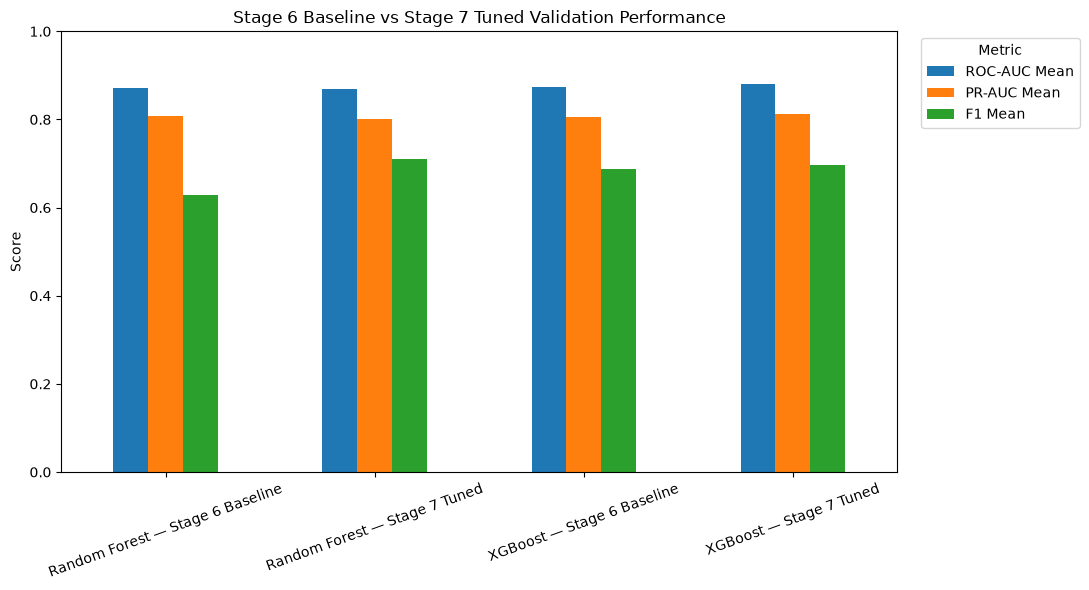

Saved: reports\figures\stage7\baseline_vs_tuned_metrics.png


In [14]:
plot_metrics = [
    "ROC-AUC Mean",
    "PR-AUC Mean",
    "F1 Mean",
]

plot_frame = stage7_shortlisted_model_comparison[
    ["Model", "Stage"] + plot_metrics
].copy()

plot_frame["Label"] = (
    plot_frame["Model"] + " — " + plot_frame["Stage"]
)
plot_frame = plot_frame.set_index("Label")[plot_metrics]

ax = plot_frame.plot(
    kind="bar",
    figsize=(11, 6),
)
ax.set_title("Stage 6 Baseline vs Stage 7 Tuned Validation Performance")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20)
ax.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()

BASELINE_TUNED_FIGURE_PATH = (
    STAGE7_FIGURE_DIR / "baseline_vs_tuned_metrics.png"
)
plt.savefig(
    BASELINE_TUNED_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print("Saved:", BASELINE_TUNED_FIGURE_PATH.relative_to(REPO_ROOT))

## 9. Class-Weight / Imbalance Findings

Imbalance handling is not assumed to help automatically.

- Random Forest search includes `None`, `balanced`, and `balanced_subsample`.
- XGBoost search includes `scale_pos_weight` values `1.0`, `1.5`, and `2.0`.

The executed best parameters below provide the evidence for whether an imbalance-aware option was selected.

No SMOTE or other synthetic oversampling is introduced.

In [15]:
for model_name in shortlisted_models:
    print("\n" + model_name)
    print("-" * len(model_name))
    print("Best parameters:", search_objects[model_name].best_params_)

    if model_name == "Random Forest":
        selected_weight = search_objects[
            model_name
        ].best_params_.get("classifier__class_weight")
        print("Selected class_weight:", selected_weight)

    elif model_name == "XGBoost":
        selected_weight = search_objects[
            model_name
        ].best_params_.get("classifier__scale_pos_weight")
        print("Selected scale_pos_weight:", selected_weight)


Random Forest
-------------
Best parameters: {'classifier__n_estimators': 400, 'classifier__min_samples_split': 30, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 0.5, 'classifier__max_depth': 20, 'classifier__class_weight': 'balanced'}
Selected class_weight: balanced

XGBoost
-------
Best parameters: {'classifier__subsample': 0.9, 'classifier__scale_pos_weight': 1.0, 'classifier__reg_lambda': 5.0, 'classifier__reg_alpha': 1.0, 'classifier__n_estimators': 600, 'classifier__min_child_weight': 1, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8}
Selected scale_pos_weight: 1.0


## 10. Feature-Ablation Decision

No feature ablation is performed in this notebook.

Stage 6 did not provide concrete evidence that the finalized engineered predictors were harming chronological validation performance, and Stage 4 intentionally retained these features after leakage and timing review. Therefore Stage 7 keeps **all 32 finalized predictors**.

This avoids changing an already finalized feature contract without supporting evidence. No PCA, RFE, aggressive automatic feature selection, or ad-hoc feature removal is introduced.

`has_agent` and `has_company` remain included as finalized replacements for the raw agent/company identifiers.

Because no ablation experiment is performed, this notebook correctly does **not** create a `stage7_feature_ablation_results.csv` file.

## 11. Pre-Registered Final Model Selection Rule

The final algorithm is selected **before threshold optimization and before final-test access**.

1. Primary criterion: highest mean tuned chronological CV **ROC-AUC**.
2. If the strongest candidates differ by more than `0.005` ROC-AUC, select the higher-ROC-AUC model.
3. If the difference is `<= 0.005`, treat them as practically close **for this project**. The `0.005` value is a project-defined practical tolerance, not a universal significance threshold.
4. For practically close models, use a deterministic, non-weighted secondary ordering:
   - higher PR-AUC;
   - then higher F1;
   - then higher recall;
   - then higher precision;
   - then lower ROC-AUC fold standard deviation;
   - then lower mean fitting time.
5. Interpretability and deployment complexity are discussed alongside the numerical evidence; no arbitrary weighted score is created.

Only one model proceeds to threshold optimization.

In [16]:
tuned_selection_table = (
    stage7_tuned_summary[
        [
            "Model",
            "ROC-AUC Mean",
            "ROC-AUC Std",
            "PR-AUC Mean",
            "F1 Mean",
            "Recall Mean",
            "Precision Mean",
            "Fit Time Seconds Mean",
        ]
    ]
    .sort_values("ROC-AUC Mean", ascending=False)
    .reset_index(drop=True)
)

best_tuned_roc_auc = tuned_selection_table.loc[
    0,
    "ROC-AUC Mean",
]

tuned_selection_table["ROC-AUC Gap from Best"] = (
    best_tuned_roc_auc
    - tuned_selection_table["ROC-AUC Mean"]
)
tuned_selection_table["Within 0.005 of Best"] = (
    tuned_selection_table["ROC-AUC Gap from Best"]
    <= PRACTICAL_ROC_AUC_GAP
)

close_tuned_candidates = tuned_selection_table[
    tuned_selection_table["Within 0.005 of Best"]
].copy()

if len(close_tuned_candidates) == 1:
    selected_model_name = close_tuned_candidates.iloc[0]["Model"]
    selection_reason = (
        f"{selected_model_name} had the highest mean chronological CV "
        "ROC-AUC and no competing tuned model was within the project's "
        "0.005 practical-closeness tolerance."
    )
else:
    ordered_close = close_tuned_candidates.sort_values(
        by=[
            "PR-AUC Mean",
            "F1 Mean",
            "Recall Mean",
            "Precision Mean",
            "ROC-AUC Std",
            "Fit Time Seconds Mean",
        ],
        ascending=[
            False,
            False,
            False,
            False,
            True,
            True,
        ],
    ).reset_index(drop=True)

    selected_model_name = ordered_close.iloc[0]["Model"]
    selection_reason = (
        f"The tuned models were within {PRACTICAL_ROC_AUC_GAP:.3f} "
        "ROC-AUC, so the pre-registered secondary ordering was applied. "
        f"{selected_model_name} ranked first under that ordering."
    )

selected_search = search_objects[selected_model_name]
selected_tuned_pipeline = best_estimators[selected_model_name]
selected_tuned_summary = stage7_tuned_summary[
    stage7_tuned_summary["Model"] == selected_model_name
].iloc[0]

display(
    tuned_selection_table.style.format(
        {
            col: "{:.4f}"
            for col in tuned_selection_table.columns
            if col not in {
                "Model",
                "Within 0.005 of Best",
            }
        }
    )
)

print("Selected final algorithm:", selected_model_name)
print("Reason:", selection_reason)
print("\nSelected hyperparameters:")
print(selected_search.best_params_)

,Model,ROC-AUC Mean,ROC-AUC Std,PR-AUC Mean,F1 Mean,Recall Mean,Precision Mean,Fit Time Seconds Mean,ROC-AUC Gap from Best,Within 0.005 of Best
0,XGBoost,0.8804,0.0307,0.8133,0.6970,0.6420,0.7712,4.8709,0.0000,True
1,Random Forest,0.8700,0.0373,0.8014,0.7101,0.6960,0.7333,112.6578,0.0104,False


Selected final algorithm: XGBoost
Reason: XGBoost had the highest mean chronological CV ROC-AUC and no competing tuned model was within the project's 0.005 practical-closeness tolerance.

Selected hyperparameters:
{'classifier__subsample': 0.9, 'classifier__scale_pos_weight': 1.0, 'classifier__reg_lambda': 5.0, 'classifier__reg_alpha': 1.0, 'classifier__n_estimators': 600, 'classifier__min_child_weight': 1, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8}


## 12. Training-Only Threshold Optimization

Algorithm, hyperparameters, imbalance setting, and the 32-feature set are now fixed.

The classification threshold is selected next using **only chronological out-of-fold probabilities from the training data**.

- Each fold refits the frozen preprocessing + classifier Pipeline on that fold's earlier training window.
- Probabilities are generated only for the later validation window.
- Candidate thresholds from `0.10` to `0.90` are evaluated.
- Cancellation-class **F1** is the threshold-selection objective because no formal business false-positive/false-negative cost ratio has been supplied.
- Precision and recall are retained so the trade-off is visible.
- ROC-AUC and PR-AUC do not change with the classification threshold.

In [17]:
def generate_oof_probabilities(
    pipeline,
    X,
    y,
    folds,
):
    """Generate training-only chronological OOF probabilities."""
    oof_frames = []

    for fold_number, (train_idx, validation_idx) in enumerate(
        folds,
        start=1,
    ):
        fold_pipeline = clone(pipeline)

        fold_pipeline.fit(
            X.iloc[train_idx],
            y.iloc[train_idx],
        )

        probabilities = fold_pipeline.predict_proba(
            X.iloc[validation_idx]
        )[:, 1]

        oof_frames.append(
            pd.DataFrame(
                {
                    "Fold": fold_number,
                    "Row Index": validation_idx,
                    "Actual": y.iloc[validation_idx].to_numpy(),
                    "Probability Cancelled": probabilities,
                }
            )
        )

    oof = pd.concat(oof_frames, ignore_index=True)

    assert not oof["Row Index"].duplicated().any()
    assert oof["Probability Cancelled"].between(0, 1).all()

    return oof


selected_model_oof = generate_oof_probabilities(
    pipeline=selected_tuned_pipeline,
    X=X_train,
    y=y_train,
    folds=time_folds,
)

print(
    "Training-only OOF predictions generated:",
    len(selected_model_oof),
)
print(
    "OOF ROC-AUC:",
    f"{roc_auc_score(selected_model_oof['Actual'], selected_model_oof['Probability Cancelled']):.6f}",
)
print(
    "OOF PR-AUC:",
    f"{average_precision_score(selected_model_oof['Actual'], selected_model_oof['Probability Cancelled']):.6f}",
)

Training-only OOF predictions generated: 48009
OOF ROC-AUC: 0.881308
OOF PR-AUC: 0.825624


In [18]:
threshold_rows = []

for threshold in np.round(
    np.arange(0.10, 0.901, 0.01),
    2,
):
    predictions = (
        selected_model_oof["Probability Cancelled"].to_numpy()
        >= threshold
    ).astype(int)

    actual = selected_model_oof["Actual"].to_numpy()

    threshold_rows.append(
        {
            "Threshold": float(threshold),
            "Accuracy": accuracy_score(actual, predictions),
            "Precision": precision_score(
                actual,
                predictions,
                zero_division=0,
            ),
            "Recall": recall_score(
                actual,
                predictions,
                zero_division=0,
            ),
            "F1": f1_score(
                actual,
                predictions,
                zero_division=0,
            ),
        }
    )

stage7_threshold_results = pd.DataFrame(threshold_rows)
stage7_threshold_results["Distance from 0.5"] = (
    stage7_threshold_results["Threshold"] - 0.5
).abs()

# Deterministic tie handling:
# 1) highest F1
# 2) closest threshold to 0.5
# 3) lower threshold if still tied
threshold_ranking = stage7_threshold_results.sort_values(
    by=[
        "F1",
        "Distance from 0.5",
        "Threshold",
    ],
    ascending=[
        False,
        True,
        True,
    ],
).reset_index(drop=True)

selected_threshold = float(
    threshold_ranking.loc[0, "Threshold"]
)

STAGE7_THRESHOLD_RESULTS_PATH = (
    MODELING_REPORT_DIR / "stage7_threshold_results.csv"
)

stage7_threshold_results.drop(
    columns="Distance from 0.5"
).to_csv(
    STAGE7_THRESHOLD_RESULTS_PATH,
    index=False,
)

best_threshold_row = threshold_ranking.iloc[0]

print("Selected training-only probability threshold:", selected_threshold)
print(
    "OOF metrics at selected threshold: "
    f"F1={best_threshold_row['F1']:.4f}, "
    f"Precision={best_threshold_row['Precision']:.4f}, "
    f"Recall={best_threshold_row['Recall']:.4f}, "
    f"Accuracy={best_threshold_row['Accuracy']:.4f}"
)

near_threshold = stage7_threshold_results[
    stage7_threshold_results["Threshold"].between(
        max(0.10, selected_threshold - 0.05),
        min(0.90, selected_threshold + 0.05),
    )
].copy()

display(
    near_threshold[
        [
            "Threshold",
            "Precision",
            "Recall",
            "F1",
            "Accuracy",
        ]
    ].style.format(
        {
            "Threshold": "{:.2f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1": "{:.4f}",
            "Accuracy": "{:.4f}",
        }
    )
)

print("Saved:", STAGE7_THRESHOLD_RESULTS_PATH.relative_to(REPO_ROOT))

Selected training-only probability threshold: 0.33
OOF metrics at selected threshold: F1=0.7355, Precision=0.6858, Recall=0.7929, Accuracy=0.7921


,Threshold,Precision,Recall,F1,Accuracy
18,0.28,0.6502,0.8307,0.7294,0.7753
19,0.29,0.6592,0.8244,0.7326,0.7806
20,0.30,0.6671,0.8163,0.7342,0.7845
21,0.31,0.6737,0.8082,0.7349,0.7874
22,0.32,0.6799,0.8001,0.7351,0.7897
23,0.33,0.6858,0.7929,0.7355,0.7921
24,0.34,0.6897,0.7841,0.7339,0.7927
25,0.35,0.6942,0.7743,0.7321,0.7933
26,0.36,0.6985,0.7649,0.7302,0.7939
27,0.37,0.7038,0.7586,0.7302,0.7956


Saved: reports\modeling\stage7_threshold_results.csv


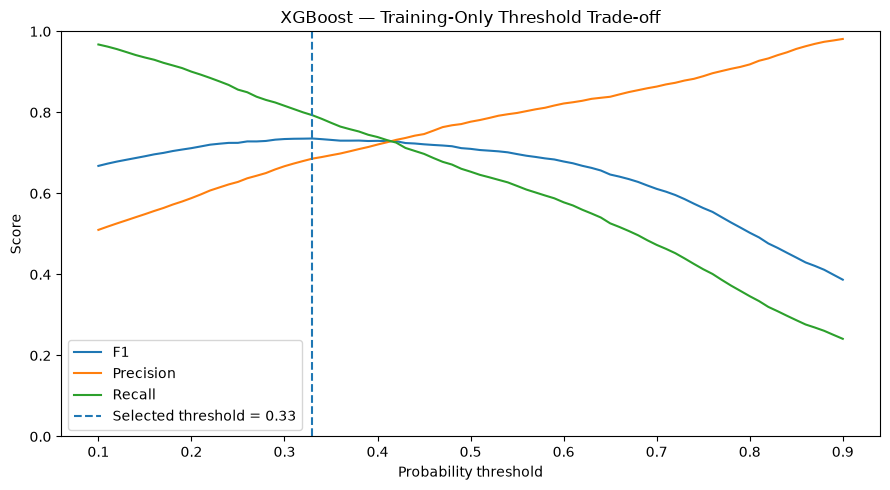

Saved: reports\figures\stage7\threshold_precision_recall_f1_curve.png


In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    stage7_threshold_results["Threshold"],
    stage7_threshold_results["F1"],
    label="F1",
)
ax.plot(
    stage7_threshold_results["Threshold"],
    stage7_threshold_results["Precision"],
    label="Precision",
)
ax.plot(
    stage7_threshold_results["Threshold"],
    stage7_threshold_results["Recall"],
    label="Recall",
)

ax.axvline(
    selected_threshold,
    linestyle="--",
    label=f"Selected threshold = {selected_threshold:.2f}",
)

ax.set_title(
    f"{selected_model_name} — Training-Only Threshold Trade-off"
)
ax.set_xlabel("Probability threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()

THRESHOLD_FIGURE_PATH = (
    STAGE7_FIGURE_DIR / "threshold_precision_recall_f1_curve.png"
)
fig.savefig(
    THRESHOLD_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print("Saved:", THRESHOLD_FIGURE_PATH.relative_to(REPO_ROOT))

# FINAL DECISION LOCK

Everything that can influence model choice is frozen **before final-test access**.

The next code cell records:

- final algorithm;
- tuned hyperparameters;
- all 32 finalized predictors;
- imbalance/class-weight setting;
- frozen probability threshold;
- preprocessing definition;
- chronological CV design;
- primary model-selection metric;
- optimized training-CV evidence;
- reason for final selection.

The lock is written to:

`reports/modeling/final_selection_lock.json`

Only after that file has been successfully written may this notebook read the final-test CSVs.

In [20]:
def to_json_safe(value):
    """Convert common NumPy/pandas objects to JSON-safe Python values."""
    if isinstance(value, dict):
        return {
            str(k): to_json_safe(v)
            for k, v in value.items()
        }

    if isinstance(value, (list, tuple)):
        return [to_json_safe(v) for v in value]

    if isinstance(value, (np.integer,)):
        return int(value)

    if isinstance(value, (np.floating,)):
        value = float(value)
        return value if np.isfinite(value) else None

    if isinstance(value, float):
        return value if np.isfinite(value) else None

    if isinstance(value, (pd.Timestamp, datetime)):
        return value.isoformat()

    if isinstance(value, Path):
        return str(value)

    return value


selected_search_params = {
    key.replace("classifier__", ""): value
    for key, value in selected_search.best_params_.items()
}

if selected_model_name == "Random Forest":
    imbalance_setting = {
        "parameter": "class_weight",
        "value": selected_search.best_params_.get(
            "classifier__class_weight"
        ),
    }
elif selected_model_name == "XGBoost":
    imbalance_setting = {
        "parameter": "scale_pos_weight",
        "value": selected_search.best_params_.get(
            "classifier__scale_pos_weight"
        ),
    }
else:
    imbalance_setting = {
        "parameter": "class_weight",
        "value": selected_search.best_params_.get(
            "classifier__class_weight"
        ),
    }

optimized_cv_metrics = {
    "roc_auc_mean": selected_tuned_summary["ROC-AUC Mean"],
    "roc_auc_std": selected_tuned_summary["ROC-AUC Std"],
    "pr_auc_mean": selected_tuned_summary["PR-AUC Mean"],
    "precision_mean_at_0_5": selected_tuned_summary[
        "Precision Mean"
    ],
    "recall_mean_at_0_5": selected_tuned_summary[
        "Recall Mean"
    ],
    "f1_mean_at_0_5": selected_tuned_summary["F1 Mean"],
    "accuracy_mean_at_0_5": selected_tuned_summary[
        "Accuracy Mean"
    ],
}

final_selection_lock = {
    "stage": "Stage 7 final decision lock",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "selected_algorithm": selected_model_name,
    "selected_hyperparameters": selected_search_params,
    "feature_set": EXPECTED_PREDICTORS,
    "feature_count": len(EXPECTED_PREDICTORS),
    "feature_ablation_performed": False,
    "feature_decision": (
        "All 32 finalized Stage 4 predictors retained; "
        "no training evidence required ablation."
    ),
    "imbalance_setting": imbalance_setting,
    "probability_threshold": selected_threshold,
    "threshold_objective": (
        "Maximum cancellation-class F1 on training-only chronological "
        "out-of-fold probabilities."
    ),
    "preprocessing": {
        "general_numeric": (
            "SimpleImputer(strategy='median') + RobustScaler()"
        ),
        "children": (
            "SimpleImputer(strategy='most_frequent') + RobustScaler()"
        ),
        "binary": "passthrough",
        "categorical": (
            "SimpleImputer(strategy='constant', fill_value='Unknown') "
            "+ OneHotEncoder(handle_unknown='ignore')"
        ),
    },
    "cv_strategy": (
        "Five-fold grouped expanding-window chronological validation; "
        "initial ~50% training window followed by five ~10% validation "
        "periods; complete reconstructed booking_date groups kept intact."
    ),
    "cv_boundaries": [
        boundary.date().isoformat()
        for boundary in fold_boundaries
    ],
    "primary_selection_metric": "mean chronological CV ROC-AUC",
    "practical_closeness_tolerance": PRACTICAL_ROC_AUC_GAP,
    "optimized_cv_metrics": optimized_cv_metrics,
    "selection_reason": selection_reason,
    "final_test_accessed_before_lock": False,
}

FINAL_SELECTION_LOCK_PATH = (
    MODELING_REPORT_DIR / "final_selection_lock.json"
)

with FINAL_SELECTION_LOCK_PATH.open(
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        to_json_safe(final_selection_lock),
        f,
        indent=2,
        ensure_ascii=False,
    )

assert FINAL_SELECTION_LOCK_PATH.exists()
assert FINAL_SELECTION_LOCK_PATH.stat().st_size > 0

FINAL_DECISION_LOCK_WRITTEN = True

print("FINAL DECISION LOCK WRITTEN")
print("Path:", FINAL_SELECTION_LOCK_PATH.relative_to(REPO_ROOT))
print("Selected algorithm:", selected_model_name)
print("Selected hyperparameters:", selected_search_params)
print("Feature count:", len(EXPECTED_PREDICTORS))
print("Imbalance setting:", imbalance_setting)
print("Frozen threshold:", selected_threshold)
print("Primary metric: mean chronological CV ROC-AUC")
print("Reason:", selection_reason)
print("\nFinal test has not been loaded yet.")

FINAL DECISION LOCK WRITTEN
Path: reports\modeling\final_selection_lock.json
Selected algorithm: XGBoost
Selected hyperparameters: {'subsample': 0.9, 'scale_pos_weight': 1.0, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Feature count: 32
Imbalance setting: {'parameter': 'scale_pos_weight', 'value': 1.0}
Frozen threshold: 0.33
Primary metric: mean chronological CV ROC-AUC
Reason: XGBoost had the highest mean chronological CV ROC-AUC and no competing tuned model was within the project's 0.005 practical-closeness tolerance.

Final test has not been loaded yet.


## 13. Final Test Access — Only After the Decision Lock

The final decision is now frozen.

The chronological final-test files are loaded for the first time in this notebook:

- `data/processed/X_test_engineered.csv`
- `data/processed/y_test.csv`

From this point onward, final-test results are **evaluation evidence only**. No algorithm, hyperparameter, feature, class-weight, or threshold decision may be changed after observing them.

In [21]:
assert FINAL_DECISION_LOCK_WRITTEN, (
    "Final test access is blocked until the FINAL DECISION LOCK is written."
)

X_TEST_PATH = (
    REPO_ROOT / "data" / "processed" / "X_test_engineered.csv"
)
Y_TEST_PATH = (
    REPO_ROOT / "data" / "processed" / "y_test.csv"
)

missing_test_files = [
    str(path.relative_to(REPO_ROOT))
    for path in [X_TEST_PATH, Y_TEST_PATH]
    if not path.exists()
]

if missing_test_files:
    raise FileNotFoundError(
        "Final-test files are missing:\n"
        + "\n".join(f" - {path}" for path in missing_test_files)
    )

X_test = pd.read_csv(X_TEST_PATH)
y_test_frame = pd.read_csv(Y_TEST_PATH)

if list(y_test_frame.columns) != [TARGET]:
    raise ValueError(
        f"Expected y_test.csv to contain exactly one column named "
        f"'{TARGET}', but found: {list(y_test_frame.columns)}"
    )

y_test = y_test_frame[TARGET].copy()

X_test["booking_month"] = X_test["booking_month"].astype(str)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

EXPECTED_TEST_ROWS = 23_989

assert len(X_test) == EXPECTED_TEST_ROWS
assert len(y_test) == EXPECTED_TEST_ROWS
assert X_test.shape[1] == 32
assert list(X_test.columns) == list(X_train.columns)
assert list(X_test.columns) == EXPECTED_PREDICTORS
assert X_test.index.equals(y_test.index)
assert set(y_test.dropna().unique()) == {0, 1}
assert not y_test.isna().any()
assert not FORBIDDEN_COLUMNS.intersection(X_test.columns)
assert pd.api.types.is_string_dtype(X_test["booking_month"])

test_missing = X_test.isna().sum()
test_nonzero_missing = test_missing[test_missing > 0]
assert set(test_nonzero_missing.index).issubset(
    {"children", "country"}
), (
    "Unexpected final-test missing-value columns: "
    f"{test_nonzero_missing.to_dict()}"
)

test_arrival_date = pd.to_datetime(
    X_test["arrival_date_year"].astype(str)
    + "-"
    + X_test["arrival_date_month"].astype(str)
    + "-"
    + X_test["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d",
    errors="raise",
)

test_booking_date = (
    test_arrival_date
    - pd.to_timedelta(X_test["lead_time"], unit="D")
)

assert test_booking_date.notna().all()
assert test_booking_date.min() > booking_date_for_cv.max(), (
    "Chronological final-test contract violated: "
    "the final test does not start strictly after the training period."
)

print("Final-test integrity checks passed.")
print("Final-test predictors:", X_test.shape)
print("Final-test target:", y_test.shape)
print(
    "Final-test booking-date range:",
    test_booking_date.min().date(),
    "to",
    test_booking_date.max().date(),
)
print("\nObserved final-test missing values:")
display(test_nonzero_missing.to_frame("Missing Count"))

Final-test integrity checks passed.
Final-test predictors: (23989, 32)
Final-test target: (23989,)
Final-test booking-date range: 2017-01-12 to 2017-08-31

Observed final-test missing values:


,Missing Count
country,73


## 14. Fit the Frozen Final Pipeline on All Training Data

A fresh clone of the locked preprocessing + classifier Pipeline is fitted once on all **95,401 training observations**.

The final-test observations are never used for fitting.

In [22]:
final_pipeline = clone(selected_tuned_pipeline)

final_fit_start = time.perf_counter()
final_pipeline.fit(X_train, y_train)
final_fit_seconds = time.perf_counter() - final_fit_start

print("Final frozen pipeline fitted on training rows:", len(X_train))
print(f"Final full-training fit time: {final_fit_seconds:.2f} seconds")
print("Final-test rows used for fitting: 0")

Final frozen pipeline fitted on training rows: 95401
Final full-training fit time: 7.25 seconds
Final-test rows used for fitting: 0


## 15. One Final Evaluation on the Untouched Chronological Test Set

The frozen model is now evaluated exactly once.

- Probabilities come from `pipeline.predict_proba(...)`.
- Class predictions use the **frozen custom threshold**, not the classifier's default `0.5` decision rule.
- ROC-AUC and PR-AUC use probabilities and are threshold-independent.
- No alternative model is evaluated on this final test set.

In [23]:
assert FINAL_DECISION_LOCK_WRITTEN
assert not FINAL_TEST_EVALUATED_THIS_RUN, (
    "The final-test evaluation cell has already run in this notebook run. "
    "Restart or run the notebook from the top before intentionally repeating "
    "the entire reproducible workflow."
)

final_test_probability = final_pipeline.predict_proba(
    X_test
)[:, 1]

final_test_prediction = (
    final_test_probability >= selected_threshold
).astype(int)

final_test_metrics = {
    "accuracy": accuracy_score(
        y_test,
        final_test_prediction,
    ),
    "precision_class_1": precision_score(
        y_test,
        final_test_prediction,
        pos_label=1,
        zero_division=0,
    ),
    "recall_class_1": recall_score(
        y_test,
        final_test_prediction,
        pos_label=1,
        zero_division=0,
    ),
    "f1_class_1": f1_score(
        y_test,
        final_test_prediction,
        pos_label=1,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_test,
        final_test_probability,
    ),
    "pr_auc_average_precision": average_precision_score(
        y_test,
        final_test_probability,
    ),
    "probability_threshold": selected_threshold,
    "rows": len(y_test),
}

FINAL_TEST_EVALUATED_THIS_RUN = True

print("FINAL CHRONOLOGICAL TEST METRICS")
print("=" * 45)
for metric_name, value in final_test_metrics.items():
    if isinstance(value, float):
        print(f"{metric_name}: {value:.6f}")
    else:
        print(f"{metric_name}: {value}")

FINAL CHRONOLOGICAL TEST METRICS
accuracy: 0.745884
precision_class_1: 0.564013
recall_class_1: 0.853591
f1_class_1: 0.679225
roc_auc: 0.863732
pr_auc_average_precision: 0.754753
probability_threshold: 0.330000
rows: 23989


In [24]:
FINAL_TEST_METRICS_JSON_PATH = (
    MODELING_REPORT_DIR / "final_test_metrics.json"
)
FINAL_TEST_METRICS_CSV_PATH = (
    MODELING_REPORT_DIR / "final_test_metrics.csv"
)

with FINAL_TEST_METRICS_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        to_json_safe(final_test_metrics),
        f,
        indent=2,
    )

pd.DataFrame(
    [
        {
            "Metric": key,
            "Value": value,
        }
        for key, value in final_test_metrics.items()
    ]
).to_csv(
    FINAL_TEST_METRICS_CSV_PATH,
    index=False,
)

print("Saved:", FINAL_TEST_METRICS_JSON_PATH.relative_to(REPO_ROOT))
print("Saved:", FINAL_TEST_METRICS_CSV_PATH.relative_to(REPO_ROOT))

Saved: reports\modeling\final_test_metrics.json
Saved: reports\modeling\final_test_metrics.csv


## 16. Final Evaluation Figures

The confusion matrices use the frozen custom threshold. The ROC and Precision–Recall curves use the same single set of final-test probabilities already generated above; they do not trigger another model comparison or another model-selection decision.

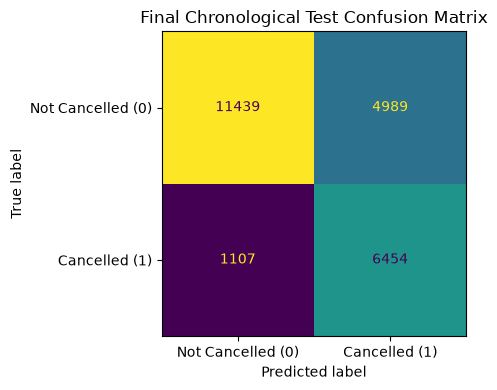

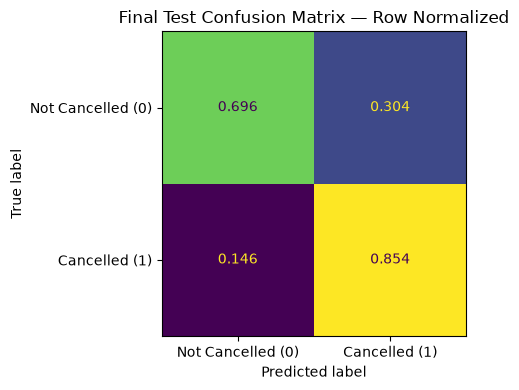

Saved: reports\figures\stage7\final_confusion_matrix.png
Saved: reports\figures\stage7\final_confusion_matrix_normalized.png


In [25]:
raw_cm = confusion_matrix(
    y_test,
    final_test_prediction,
    labels=[0, 1],
)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=raw_cm,
    display_labels=[
        "Not Cancelled (0)",
        "Cancelled (1)",
    ],
).plot(
    ax=ax,
    values_format="d",
    colorbar=False,
)
ax.set_title(
    "Final Chronological Test Confusion Matrix"
)
fig.tight_layout()

FINAL_CM_PATH = (
    STAGE7_FIGURE_DIR / "final_confusion_matrix.png"
)
fig.savefig(
    FINAL_CM_PATH,
    dpi=150,
    bbox_inches="tight",
)
plt.show()

normalized_cm = confusion_matrix(
    y_test,
    final_test_prediction,
    labels=[0, 1],
    normalize="true",
)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=normalized_cm,
    display_labels=[
        "Not Cancelled (0)",
        "Cancelled (1)",
    ],
).plot(
    ax=ax,
    values_format=".3f",
    colorbar=False,
)
ax.set_title(
    "Final Test Confusion Matrix — Row Normalized"
)
fig.tight_layout()

FINAL_CM_NORMALIZED_PATH = (
    STAGE7_FIGURE_DIR
    / "final_confusion_matrix_normalized.png"
)
fig.savefig(
    FINAL_CM_NORMALIZED_PATH,
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print("Saved:", FINAL_CM_PATH.relative_to(REPO_ROOT))
print("Saved:", FINAL_CM_NORMALIZED_PATH.relative_to(REPO_ROOT))

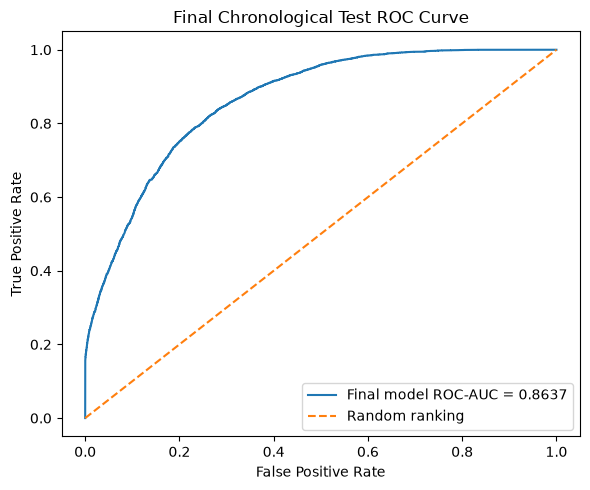

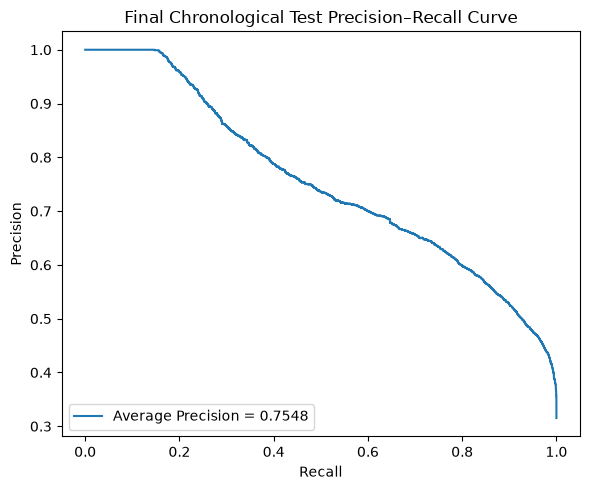

Saved: reports\figures\stage7\final_roc_curve.png
Saved: reports\figures\stage7\final_precision_recall_curve.png


In [26]:
fpr, tpr, _ = roc_curve(
    y_test,
    final_test_probability,
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(
    fpr,
    tpr,
    label=f"Final model ROC-AUC = {final_test_metrics['roc_auc']:.4f}",
)
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random ranking",
)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Final Chronological Test ROC Curve")
ax.legend(loc="lower right")
fig.tight_layout()

FINAL_ROC_PATH = (
    STAGE7_FIGURE_DIR / "final_roc_curve.png"
)
fig.savefig(
    FINAL_ROC_PATH,
    dpi=150,
    bbox_inches="tight",
)
plt.show()

pr_precision, pr_recall, _ = precision_recall_curve(
    y_test,
    final_test_probability,
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(
    pr_recall,
    pr_precision,
    label=(
        "Average Precision = "
        f"{final_test_metrics['pr_auc_average_precision']:.4f}"
    ),
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(
    "Final Chronological Test Precision–Recall Curve"
)
ax.legend(loc="lower left")
fig.tight_layout()

FINAL_PR_PATH = (
    STAGE7_FIGURE_DIR / "final_precision_recall_curve.png"
)
fig.savefig(
    FINAL_PR_PATH,
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print("Saved:", FINAL_ROC_PATH.relative_to(REPO_ROOT))
print("Saved:", FINAL_PR_PATH.relative_to(REPO_ROOT))

## 17. Save the Deployable Final Model and Metadata

The joblib artifact stores the **complete fitted Pipeline**:

`finalized preprocessing → trained classifier`

It does **not** embed the custom probability threshold. Standard `Pipeline.predict()` would still use the estimator's normal class-decision rule.

Therefore the threshold is stored explicitly in `final_model_metadata.json`. The future backend must call:

`pipeline.predict_proba(...)`

and apply the saved threshold itself.

In [27]:
FINAL_PIPELINE_PATH = (
    MODELS_DIR / "final_hotel_cancellation_pipeline.joblib"
)
FINAL_METADATA_PATH = (
    MODELS_DIR / "final_model_metadata.json"
)

joblib.dump(
    final_pipeline,
    FINAL_PIPELINE_PATH,
)

final_classifier = final_pipeline.named_steps["classifier"]

final_model_metadata = {
    "artifact_name": FINAL_PIPELINE_PATH.name,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "model_name": selected_model_name,
    "model_class": (
        f"{final_classifier.__class__.__module__}."
        f"{final_classifier.__class__.__name__}"
    ),
    "selected_hyperparameters": selected_search_params,
    "imbalance_setting": imbalance_setting,
    "probability_threshold": selected_threshold,
    "threshold_is_external_to_pipeline_predict": True,
    "backend_prediction_rule": (
        "Call pipeline.predict_proba(engineered_32_column_input)[:, 1] "
        "and classify as Cancelled when probability >= saved threshold."
    ),
    "predictor_columns_in_order": EXPECTED_PREDICTORS,
    "feature_count": len(EXPECTED_PREDICTORS),
    "categorical_columns": CATEGORICAL_COLUMNS,
    "numeric_columns_scaled": NUMERIC_COLUMNS_TO_SCALE,
    "children_column": CHILDREN_COLUMN,
    "binary_columns": BINARY_COLUMNS,
    "class_labels": {
        "0": "Not Cancelled",
        "1": "Cancelled",
    },
    "training_rows": len(X_train),
    "final_test_rows": len(X_test),
    "chronological_training_cutoff": (
        booking_date_for_cv.max().date().isoformat()
    ),
    "final_test_start_booking_date": (
        test_booking_date.min().date().isoformat()
    ),
    "cv_method": final_selection_lock["cv_strategy"],
    "cv_boundaries": final_selection_lock["cv_boundaries"],
    "primary_selection_metric": "mean chronological CV ROC-AUC",
    "practical_closeness_tolerance": PRACTICAL_ROC_AUC_GAP,
    "optimized_cv_metrics": optimized_cv_metrics,
    "threshold_oof_metrics": {
        "f1": best_threshold_row["F1"],
        "precision": best_threshold_row["Precision"],
        "recall": best_threshold_row["Recall"],
        "accuracy": best_threshold_row["Accuracy"],
    },
    "final_test_metrics": final_test_metrics,
    "preprocessing": final_selection_lock["preprocessing"],
    "feature_ablation_performed": False,
    "python_version": platform.python_version(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "scikit_learn_version": sklearn.__version__,
    "xgboost_version": xgboost.__version__,
    "joblib_version": joblib.__version__,
}

with FINAL_METADATA_PATH.open(
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        to_json_safe(final_model_metadata),
        f,
        indent=2,
        ensure_ascii=False,
    )

assert FINAL_PIPELINE_PATH.exists()
assert FINAL_METADATA_PATH.exists()

print("Saved final pipeline:", FINAL_PIPELINE_PATH.relative_to(REPO_ROOT))
print("Saved model metadata:", FINAL_METADATA_PATH.relative_to(REPO_ROOT))
print(
    "Pipeline file size:",
    f"{FINAL_PIPELINE_PATH.stat().st_size / (1024 ** 2):.2f} MB",
)

Saved final pipeline: models\final_hotel_cancellation_pipeline.joblib
Saved model metadata: models\final_model_metadata.json
Pipeline file size: 0.90 MB


## 18. Engineered Model-Input Contract for Backend Readiness

The saved pipeline expects the finalized **32-column engineered representation**.

It does **not** directly accept arbitrary frontend fields or a raw Hotel Booking Demand row.

Backend development must later apply/reuse deterministic inference-time feature engineering so user/form inputs are converted to exactly these 32 columns, in the documented order, before `predict_proba` is called.

The generated schema records:

- model-input column;
- feature role;
- expected representation;
- whether missing values are permitted by the finalized training contract;
- observed/allowed values or training ranges where useful.

Unseen categorical values can still be transformed because the finalized encoder uses `handle_unknown="ignore"`.

In [28]:
MODEL_INPUT_SCHEMA_PATH = (
    DOCS_DIR / "model_input_schema.md"
)

schema_rows = []

for column in EXPECTED_PREDICTORS:
    if column in CATEGORICAL_COLUMNS:
        role = "Categorical"
        data_type = "string/category"
        missing_permitted = (
            "Yes — imputed to Unknown"
            if column == "country"
            else "No in finalized training data"
        )

        observed_values = sorted(
            X_train[column].dropna().astype(str).unique().tolist()
        )

        if len(observed_values) <= 20:
            validation_note = (
                "Training-observed categories: "
                + ", ".join(observed_values)
                + ". Unseen values are accepted by "
                  "OneHotEncoder(handle_unknown='ignore')."
            )
        else:
            validation_note = (
                f"{len(observed_values)} categories observed in training. "
                "Unseen values are accepted by "
                "OneHotEncoder(handle_unknown='ignore')."
            )

    elif column in BINARY_COLUMNS:
        role = "Binary"
        data_type = "integer"
        missing_permitted = "No"
        validation_note = "Allowed model representation: 0 or 1."

    elif column in CHILDREN_COLUMN:
        role = "Numeric — special imputation"
        data_type = "numeric"
        missing_permitted = (
            "Yes — most-frequent imputation in pipeline"
        )
        col_min = X_train[column].min(skipna=True)
        col_max = X_train[column].max(skipna=True)
        validation_note = (
            f"Training-observed range: {col_min:g} to {col_max:g}. "
            "RobustScaler applied after imputation."
        )

    else:
        role = "Numeric"
        data_type = "numeric"
        missing_permitted = "No in finalized training data"
        col_min = X_train[column].min(skipna=True)
        col_max = X_train[column].max(skipna=True)
        validation_note = (
            f"Training-observed range: {col_min:g} to {col_max:g}. "
            "RobustScaler applied. These observed ranges are documentation, "
            "not automatic hard limits for future backend validation."
        )

    schema_rows.append(
        {
            "Column": column,
            "Role": role,
            "Data type": data_type,
            "Missing permitted": missing_permitted,
            "Allowed / observed values or notes": validation_note,
        }
    )

schema_df = pd.DataFrame(schema_rows)

schema_lines = [
    "# Final Model Input Schema",
    "",
    "## Purpose",
    "",
    (
        "The saved `final_hotel_cancellation_pipeline.joblib` expects the "
        "finalized **32-column engineered model-input representation**. "
        "It does not directly accept arbitrary raw frontend fields."
    ),
    "",
    (
        "During backend development, deterministic inference-time feature "
        "engineering must convert validated user/form inputs into exactly "
        "these columns and this column order before prediction."
    ),
    "",
    (
        "The backend must call `pipeline.predict_proba(...)` and apply the "
        "probability threshold stored in `models/final_model_metadata.json`."
    ),
    "",
    "## Column contract",
    "",
    "| Column | Role | Data type | Missing permitted | Allowed / observed values or notes |",
    "|---|---|---|---|---|",
]

for row in schema_rows:
    values = [
        str(row["Column"]),
        str(row["Role"]),
        str(row["Data type"]),
        str(row["Missing permitted"]),
        str(row["Allowed / observed values or notes"]),
    ]
    values = [
        value.replace("|", "\\|").replace("\n", " ")
        for value in values
    ]
    schema_lines.append("| " + " | ".join(values) + " |")

schema_lines.extend(
    [
        "",
        "## Important deployment distinction",
        "",
        (
            "This schema documents the input expected by the fitted model "
            "pipeline **after deterministic feature engineering**. A future "
            "frontend should ask only for legitimate prediction-time inputs. "
            "The backend must derive engineered fields such as totals and "
            "binary indicators consistently with Notebook 02 before invoking "
            "the saved pipeline."
        ),
        "",
        (
            "Outcome/leakage fields excluded during model development must "
            "never be introduced into the backend prediction request."
        ),
        "",
    ]
)

MODEL_INPUT_SCHEMA_PATH.write_text(
    "\n".join(schema_lines),
    encoding="utf-8",
)

print("Saved:", MODEL_INPUT_SCHEMA_PATH.relative_to(REPO_ROOT))
display(schema_df)

Saved: docs\model_input_schema.md


,Column,Role,Data type,Missing permitted,Allowed / observed values or notes
0,hotel,Categorical,string/category,No in finalized training data,"Training-observed categories: City Hotel, Reso..."
1,lead_time,Numeric,numeric,No in finalized training data,Training-observed range: 0 to 737. RobustScale...
2,arrival_date_year,Numeric,numeric,No in finalized training data,Training-observed range: 2015 to 2017. RobustS...
3,arrival_date_month,Categorical,string/category,No in finalized training data,"Training-observed categories: April, August, D..."
4,arrival_date_week_number,Numeric,numeric,No in finalized training data,Training-observed range: 1 to 53. RobustScaler...
5,arrival_date_day_of_month,Numeric,numeric,No in finalized training data,Training-observed range: 1 to 31. RobustScaler...
6,stays_in_weekend_nights,Numeric,numeric,No in finalized training data,Training-observed range: 0 to 19. RobustScaler...
7,stays_in_week_nights,Numeric,numeric,No in finalized training data,Training-observed range: 0 to 50. RobustScaler...
8,adults,Numeric,numeric,No in finalized training data,Training-observed range: 0 to 55. RobustScaler...
9,children,Numeric — special imputation,numeric,Yes — most-frequent imputation in pipeline,Training-observed range: 0 to 10. RobustScaler...


## 19. Final Academic Interpretation

To avoid transcription mistakes, the next cell constructs the final interpretation directly from the **executed Stage 6 evidence, executed Stage 7 tuning results, locked threshold, and one final-test evaluation**.

After running and saving this notebook, the rendered output below is the result-dependent interpretation for the report/viva record. No model choice is changed after the test results are observed.

In [29]:
selected_baseline_row = stage6_baseline_results[
    stage6_baseline_results["Model"] == selected_model_name
].iloc[0]

selected_tuned_row = stage7_tuned_summary[
    stage7_tuned_summary["Model"] == selected_model_name
].iloc[0]

roc_change = (
    selected_tuned_row["ROC-AUC Mean"]
    - selected_baseline_row["ROC-AUC Mean"]
)

tn, fp, fn, tp = raw_cm.ravel()

cv_test_roc_gap = (
    final_test_metrics["roc_auc"]
    - selected_tuned_row["ROC-AUC Mean"]
)

imbalance_text = (
    f"{imbalance_setting['parameter']}="
    f"{imbalance_setting['value']}"
)

interpretation_md = f"""
### Stage 6 to Stage 7 result

Stage 6 shortlisted **Random Forest** and **XGBoost** because their baseline
mean chronological CV ROC-AUC values were **0.8725** and **0.8743**,
respectively. Their gap was within the project's predefined 0.005 practical
tolerance, so both were optimized using the same training-only chronological
folds.

After Stage 7 tuning, the selected final algorithm was
**{selected_model_name}**. Its mean chronological CV ROC-AUC was
**{selected_tuned_row['ROC-AUC Mean']:.4f}** compared with its Stage 6
baseline value of **{selected_baseline_row['ROC-AUC Mean']:.4f}**,
a change of **{roc_change:+.4f}**.

The selected imbalance setting was **{imbalance_text}**. This value was
chosen by the same ROC-AUC optimization search rather than being enabled
automatically.

No feature ablation was performed because Stage 6 did not provide concrete
evidence requiring a change to the finalized 32-predictor Stage 4 contract.

### Threshold decision

After the algorithm, hyperparameters, feature set, and imbalance setting were
fixed, chronological training-only OOF probabilities were generated. The
cancellation-class F1 objective selected a frozen probability threshold of
**{selected_threshold:.2f}**. At this threshold, training-only OOF
precision was **{best_threshold_row['Precision']:.4f}**, recall was
**{best_threshold_row['Recall']:.4f}**, and F1 was
**{best_threshold_row['F1']:.4f}**.

The threshold was frozen before the final-test files were loaded.

### Final chronological test performance

The single frozen final model achieved:

- **Accuracy:** {final_test_metrics['accuracy']:.4f}
- **Precision (Cancelled = 1):** {final_test_metrics['precision_class_1']:.4f}
- **Recall (Cancelled = 1):** {final_test_metrics['recall_class_1']:.4f}
- **F1 (Cancelled = 1):** {final_test_metrics['f1_class_1']:.4f}
- **ROC-AUC:** {final_test_metrics['roc_auc']:.4f}
- **PR-AUC / Average Precision:** {final_test_metrics['pr_auc_average_precision']:.4f}

The raw confusion matrix contained **{tn:,} true negatives**,
**{fp:,} false positives**, **{fn:,} false negatives**, and
**{tp:,} true positives**.

For hotel operations, a false positive is a booking flagged as cancellation
risk that ultimately remains active, while a false negative is a cancellation
the model did not identify in advance. These errors should therefore be used
as decision-support information rather than as automatic grounds for
penalizing a customer.

The final-test ROC-AUC differed from the selected model's tuned mean CV
ROC-AUC by **{cv_test_roc_gap:+.4f}**. This comparison describes temporal
generalization; it is **not** used to revisit the model decision.

### Limitations and model-governance conclusion

The data represent two Portuguese hotels from 2015–2017, so performance may
not transfer unchanged to other properties or current booking behavior.
Chronological variation across the validation folds also shows that model
performance can change over time.

The final test set was used only after the FINAL DECISION LOCK. No
post-test algorithm, hyperparameter, feature, imbalance, or threshold change
is made in this notebook.

The saved joblib artifact contains the fitted preprocessing and classifier.
The custom threshold is stored separately in model metadata; the future
backend must use `predict_proba` and apply that threshold. The pipeline
expects the finalized **32 engineered columns**, so deterministic
inference-time feature engineering is still required before frontend inputs
can be scored.
"""

display(Markdown(interpretation_md))


### Stage 6 to Stage 7 result

Stage 6 shortlisted **Random Forest** and **XGBoost** because their baseline
mean chronological CV ROC-AUC values were **0.8725** and **0.8743**,
respectively. Their gap was within the project's predefined 0.005 practical
tolerance, so both were optimized using the same training-only chronological
folds.

After Stage 7 tuning, the selected final algorithm was
**XGBoost**. Its mean chronological CV ROC-AUC was
**0.8804** compared with its Stage 6
baseline value of **0.8743**,
a change of **+0.0061**.

The selected imbalance setting was **scale_pos_weight=1.0**. This value was
chosen by the same ROC-AUC optimization search rather than being enabled
automatically.

No feature ablation was performed because Stage 6 did not provide concrete
evidence requiring a change to the finalized 32-predictor Stage 4 contract.

### Threshold decision

After the algorithm, hyperparameters, feature set, and imbalance setting were
fixed, chronological training-only OOF probabilities were generated. The
cancellation-class F1 objective selected a frozen probability threshold of
**0.33**. At this threshold, training-only OOF
precision was **0.6858**, recall was
**0.7929**, and F1 was
**0.7355**.

The threshold was frozen before the final-test files were loaded.

### Final chronological test performance

The single frozen final model achieved:

- **Accuracy:** 0.7459
- **Precision (Cancelled = 1):** 0.5640
- **Recall (Cancelled = 1):** 0.8536
- **F1 (Cancelled = 1):** 0.6792
- **ROC-AUC:** 0.8637
- **PR-AUC / Average Precision:** 0.7548

The raw confusion matrix contained **11,439 true negatives**,
**4,989 false positives**, **1,107 false negatives**, and
**6,454 true positives**.

For hotel operations, a false positive is a booking flagged as cancellation
risk that ultimately remains active, while a false negative is a cancellation
the model did not identify in advance. These errors should therefore be used
as decision-support information rather than as automatic grounds for
penalizing a customer.

The final-test ROC-AUC differed from the selected model's tuned mean CV
ROC-AUC by **-0.0167**. This comparison describes temporal
generalization; it is **not** used to revisit the model decision.

### Limitations and model-governance conclusion

The data represent two Portuguese hotels from 2015–2017, so performance may
not transfer unchanged to other properties or current booking behavior.
Chronological variation across the validation folds also shows that model
performance can change over time.

The final test set was used only after the FINAL DECISION LOCK. No
post-test algorithm, hyperparameter, feature, imbalance, or threshold change
is made in this notebook.

The saved joblib artifact contains the fitted preprocessing and classifier.
The custom threshold is stored separately in model metadata; the future
backend must use `predict_proba` and apply that threshold. The pipeline
expects the finalized **32 engineered columns**, so deterministic
inference-time feature engineering is still required before frontend inputs
can be scored.


## 20. Progress Evaluation 2 — Methodology Evidence Summary

The executed Stage 6 and Stage 7 workflow provides evidence for the
following methodological decisions and outcomes:

- why Random Forest and XGBoost were shortlisted in Stage 6;
- why RandomizedSearchCV was used for both shortlisted ensemble models;
- why the Random Forest search was intentionally smaller than the XGBoost search;
- which tuned hyperparameters were selected and what they control;
- whether the selected imbalance parameter remained neutral or changed;
- why all 32 finalized predictors were retained;
- why ROC-AUC was the primary model-selection metric;
- why PR-AUC, precision, recall, F1, accuracy, stability, and runtime were also examined;
- how the grouped expanding chronological folds prevent future-to-past validation leakage;
- why preprocessing remains inside every Pipeline;
- why threshold optimization used training-only OOF probabilities;
- what the FINAL DECISION LOCK prevents;
- why only the selected model was evaluated on the final test set;
- how to interpret the final confusion matrix;
- what is inside the joblib Pipeline and what is stored separately in metadata;
- why the backend must convert legitimate user inputs into the 32 engineered columns before prediction;
- why the model is decision support rather than certainty.

## 21. Persistent Output Summary

Notebook 04 writes only evidence/artifacts for experiments that actually occur.

Expected outputs include:

### Modelling evidence
- `reports/modeling/stage7_search_results.csv`
- `reports/modeling/stage7_shortlisted_model_comparison.csv`
- `reports/modeling/stage7_threshold_results.csv`
- `reports/modeling/final_selection_lock.json`
- `reports/modeling/final_test_metrics.json`
- `reports/modeling/final_test_metrics.csv`

### Figures
- `reports/figures/stage7/baseline_vs_tuned_metrics.png`
- `reports/figures/stage7/threshold_precision_recall_f1_curve.png`
- `reports/figures/stage7/final_confusion_matrix.png`
- `reports/figures/stage7/final_confusion_matrix_normalized.png`
- `reports/figures/stage7/final_roc_curve.png`
- `reports/figures/stage7/final_precision_recall_curve.png`

### Deployment artifacts
- `models/final_hotel_cancellation_pipeline.joblib`
- `models/final_model_metadata.json`
- `docs/model_input_schema.md`

No feature-ablation CSV is created because no ablation experiment is performed.

In [30]:
print("Stage 7 persistent outputs written to the repository:")

expected_output_paths = [
    STAGE7_SEARCH_RESULTS_PATH,
    STAGE7_COMPARISON_PATH,
    STAGE7_THRESHOLD_RESULTS_PATH,
    FINAL_SELECTION_LOCK_PATH,
    FINAL_TEST_METRICS_JSON_PATH,
    FINAL_TEST_METRICS_CSV_PATH,
    BASELINE_TUNED_FIGURE_PATH,
    THRESHOLD_FIGURE_PATH,
    FINAL_CM_PATH,
    FINAL_CM_NORMALIZED_PATH,
    FINAL_ROC_PATH,
    FINAL_PR_PATH,
    FINAL_PIPELINE_PATH,
    FINAL_METADATA_PATH,
    MODEL_INPUT_SCHEMA_PATH,
]

for path in expected_output_paths:
    if path.exists():
        size_mb = path.stat().st_size / (1024 ** 2)
        print(
            f" - {path.relative_to(REPO_ROOT)} "
            f"({size_mb:.2f} MB)"
        )
    else:
        print(
            f" - MISSING: {path.relative_to(REPO_ROOT)}"
        )

assert all(path.exists() for path in expected_output_paths), (
    "One or more expected Stage 7 persistent outputs are missing."
)

print("\nFinal-test evaluation completed:", FINAL_TEST_EVALUATED_THIS_RUN)
print("Post-test model modification performed: NO")
print("\nNotebook 04 — Stage 7 complete.")

Stage 7 persistent outputs written to the repository:
 - reports\modeling\stage7_search_results.csv (0.02 MB)
 - reports\modeling\stage7_shortlisted_model_comparison.csv (0.00 MB)
 - reports\modeling\stage7_threshold_results.csv (0.01 MB)
 - reports\modeling\final_selection_lock.json (0.00 MB)
 - reports\modeling\final_test_metrics.json (0.00 MB)
 - reports\modeling\final_test_metrics.csv (0.00 MB)
 - reports\figures\stage7\baseline_vs_tuned_metrics.png (0.06 MB)
 - reports\figures\stage7\threshold_precision_recall_f1_curve.png (0.07 MB)
 - reports\figures\stage7\final_confusion_matrix.png (0.03 MB)
 - reports\figures\stage7\final_confusion_matrix_normalized.png (0.03 MB)
 - reports\figures\stage7\final_roc_curve.png (0.05 MB)
 - reports\figures\stage7\final_precision_recall_curve.png (0.04 MB)
 - models\final_hotel_cancellation_pipeline.joblib (0.90 MB)
 - models\final_model_metadata.json (0.00 MB)
 - docs\model_input_schema.md (0.01 MB)

Final-test evaluation completed: True
Post-tes